In [101]:
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [102]:
df=pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [103]:
df['TotalCharges']=pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)
df=df.dropna()
df.drop(columns='customerID',inplace=True)
X=df.drop('Churn',axis=1)
y=df['Churn']

y=y.map({
    'No':0,
    "Yes":1
})
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [104]:
xgb_pipeline=joblib.load(
    "../models/xgboost.pkl"
)

In [105]:
xgb_model=xgb_pipeline.named_steps['model']

In [106]:
feature_names=(
    xgb_pipeline
    .named_steps['preprocessor']
    .get_feature_names_out()
)

In [107]:
importance_df=pd.DataFrame({
    "Feature":feature_names,
    "Importance":xgb_model.feature_importances_
})
importance_df=importance_df.sort_values(
    "Importance",

    ascending=False
)

In [108]:
top20=importance_df.head(20)
top20

,Feature,Importance
32,cat__Contract_Month-to-month,0.537613
12,cat__InternetService_Fiber optic,0.111519
14,cat__OnlineSecurity_No,0.044542
23,cat__TechSupport_No,0.041111
11,cat__InternetService_DSL,0.027787
42,num__tenure,0.018180
34,cat__Contract_Two year,0.017572
33,cat__Contract_One year,0.015315
10,cat__MultipleLines_Yes,0.012751
17,cat__OnlineBackup_No,0.011363


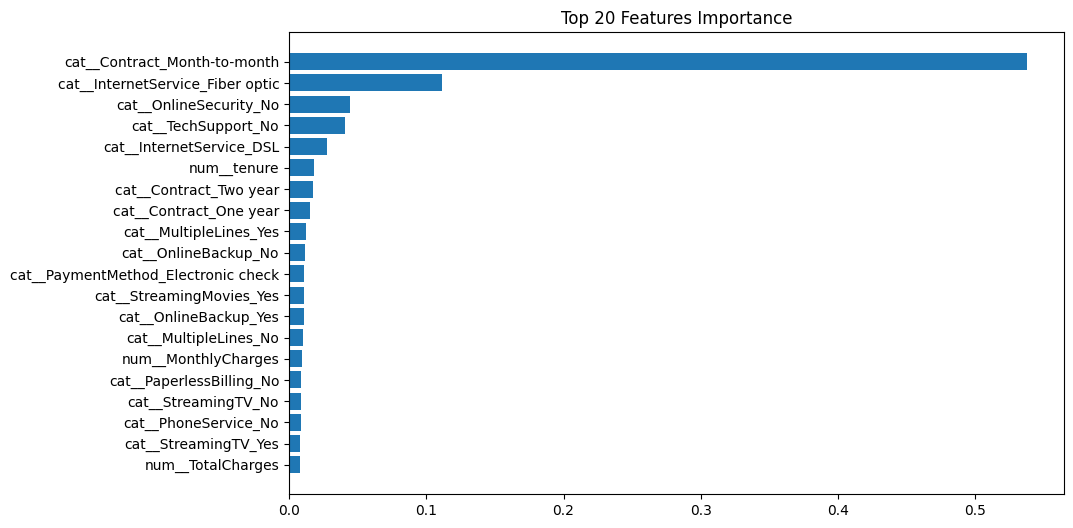

In [109]:
plt.figure(figsize=(10,6))
plt.barh(
    top20['Feature'],
    top20['Importance']
)
plt.gca().invert_yaxis()
plt.title("Top 20 Features Importance")
plt.show()

In [110]:
preprocessor=xgb_pipeline.named_steps['preprocessor']


In [111]:
X_test_transformed=preprocessor.transform(X_test)

In [112]:
explainer=shap.TreeExplainer(xgb_model)

In [113]:
shap_values=explainer.shap_values(
    X_test_transformed
)

In [114]:
feature_names = preprocessor.get_feature_names_out()

X_test_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

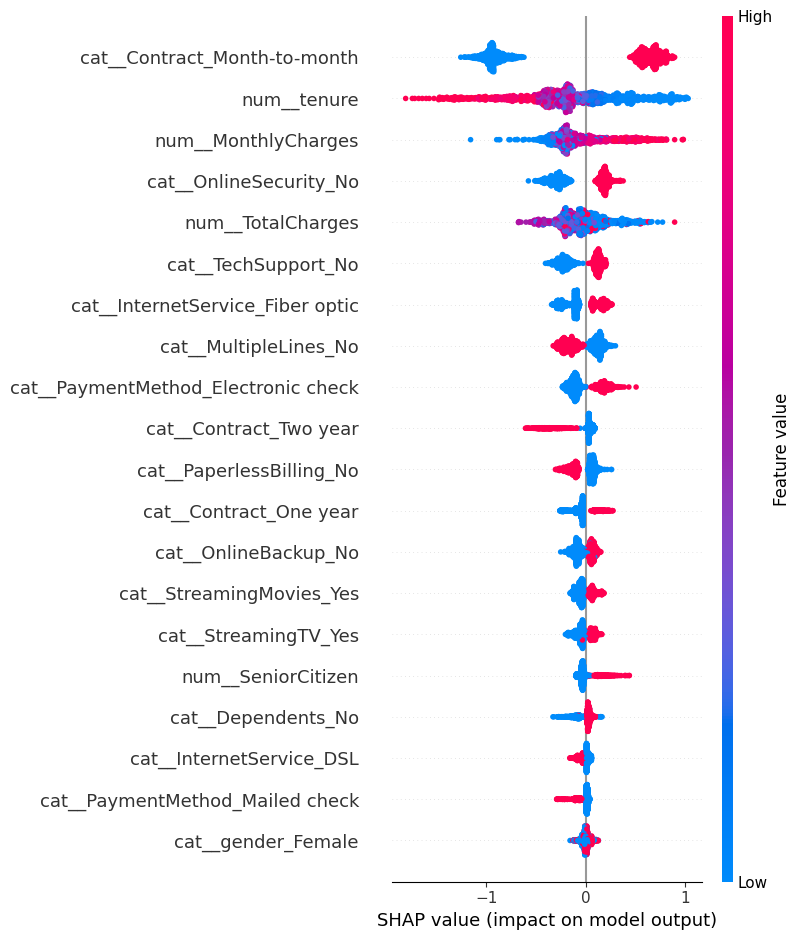

In [115]:
shap.summary_plot(
    shap_values,
    X_test_df
)

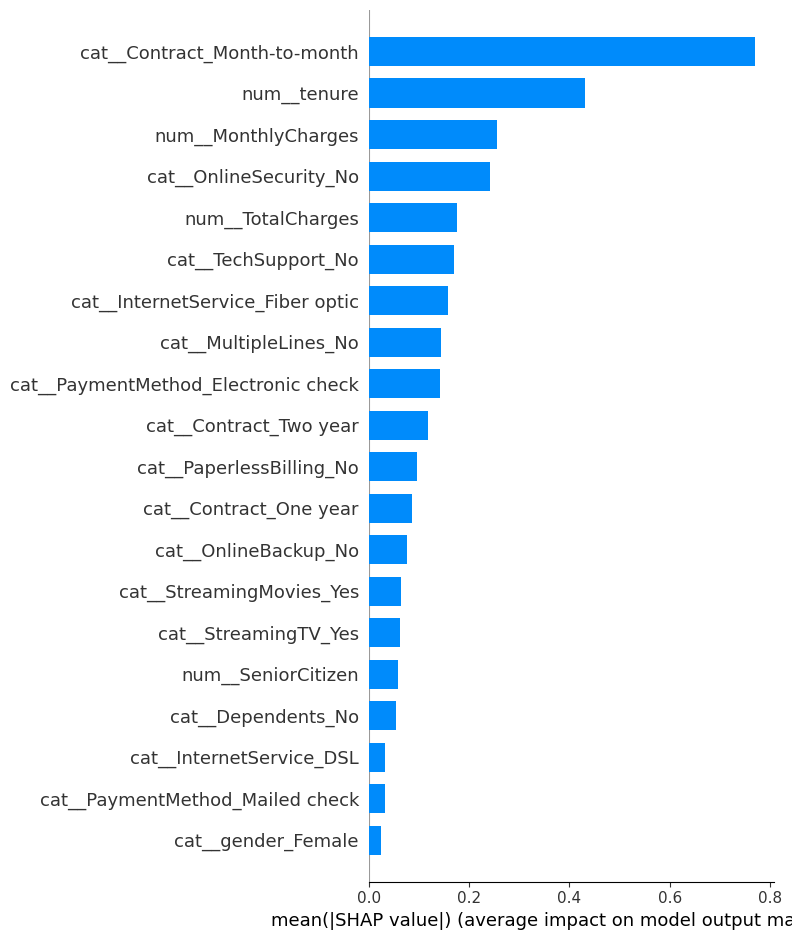

In [116]:
shap.summary_plot(
    shap_values,
    X_test_df,
    feature_names=preprocessor.get_feature_names_out(),
    plot_type="bar"
)

In [117]:

shap_values_new = explainer(X_test_df)

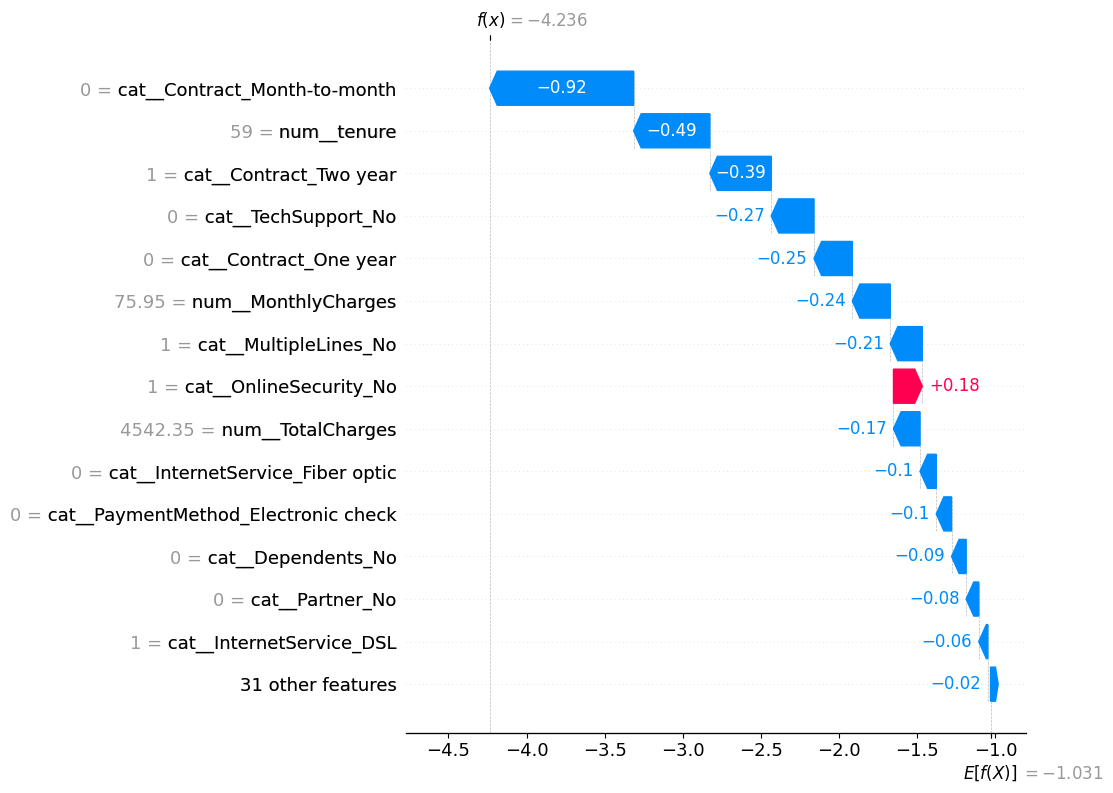

In [118]:
sample_idx = 0

shap.plots.waterfall(
    shap_values_new[sample_idx],
    max_display=15
)

In [119]:
lr_model = joblib.load("../models/logistic_regression.pkl")
xgb_model = joblib.load("../models/xgboost.pkl")
cat_model = joblib.load("../models/catboost.pkl")

In [120]:
type(lr_model)
type(xgb_model)
type(cat_model)

sklearn.pipeline.Pipeline

In [121]:
lr_prob=lr_model.predict_proba(X_test)[:,1]
xgb_prob=xgb_model.predict_proba(X_test)[:,1]
cat_prob=cat_model.predict_proba(X_test)[:,1]

In [122]:
ensemble_prob = (
    lr_prob +
    xgb_prob +
    cat_prob
) / 3

In [123]:
ensemble_pred = (
    ensemble_prob >= 0.5
).astype(int)

In [124]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, ensemble_pred))
print("Precision:", precision_score(y_test, ensemble_pred))
print("Recall:", recall_score(y_test, ensemble_pred))
print("F1:", f1_score(y_test, ensemble_pred))
print("ROC-AUC:", roc_auc_score(y_test, ensemble_prob))

Accuracy: 0.8002842928216063
Precision: 0.6485623003194888
Recall: 0.5427807486631016
F1: 0.5909752547307132
ROC-AUC: 0.8397106708563914


In [125]:
comparison=joblib.load("../reports/model_score_comparison.csv")

In [126]:
comparison.loc[len(comparison)] = [
    "Soft Voting Ensemble",
    accuracy_score(y_test, ensemble_pred),
    precision_score(y_test, ensemble_pred),
    recall_score(y_test, ensemble_pred),
    f1_score(y_test, ensemble_pred),
    roc_auc_score(y_test, ensemble_prob)
]

In [127]:
comparison.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
5,Soft Voting Ensemble,0.800284,0.648562,0.542781,0.590975,0.839711
2,XGBoost,0.796731,0.639241,0.540107,0.585507,0.837979
0,Logistic Regression,0.802416,0.644578,0.572193,0.606232,0.836426
4,CatBoost,0.795309,0.638710,0.529412,0.578947,0.834468
3,LGBoost,0.782516,0.603659,0.529412,0.564103,0.831711
1,Random Forest,0.786780,0.624161,0.497326,0.553571,0.811653
